In [5]:
from matplotlib import pyplot as plt
from functions import *

# continuous flow with reaction in one 50 ul chip and uv-vis on another 50 ul chip
# mixing due to turbulent flow in the connecting tubing results in EV+. decay, poor coorelation between tR and recorded absorbance  

# V(Ru(bpy)3, 12.5 mM, buffer) = 240 ul
# V(EV, 25 mM, buffer) = 720 ul
# V(EDTA, saturated, buffer) = 540 ul

data = f'./results/260703_Rubpy_EV_EDTA_Flow/'
start = "14-01-00-000" # recorded start time

XV = r"[EV$^{+\!\cdot\!}$]" # [XV+.]
XV0 = r"[EV$^{2\!+\!}$]$_0$" # [XV2+]0
tR = "$t_\\mathrm{R}$" # tR
c0 = solprop(cstock=25e-3, valiquot=720e-6, vsol=1.5e-3) # initial XV2+ concentration
peak = 600 # nm
e = 1.22e6 # M-1 m-1
l = 700e-6 # m

vrxn = 50 # reaction volume
vfull = 115 # full volume
tbuffer = 30 # time in seconds after the solution fully fills the reaction cell before recording

tRs = [tR*60 for tR in range(1, 8)] # residence times in seconds for 1-7 minutes
flowrates = [flowprop(tR=tR, vol=vrxn) for tR in tRs] # flow rates for each tR
points = [] # times in seconds at which to record absorbance

for i in range(len(tRs)):
    if i == 0:
        prevtime = 0
    else:
        prevtime = points[-1] + tbuffer
    points.append(prevtime + flowprop(flowrate=flowrates[i], vol=vfull) + tRs[i])

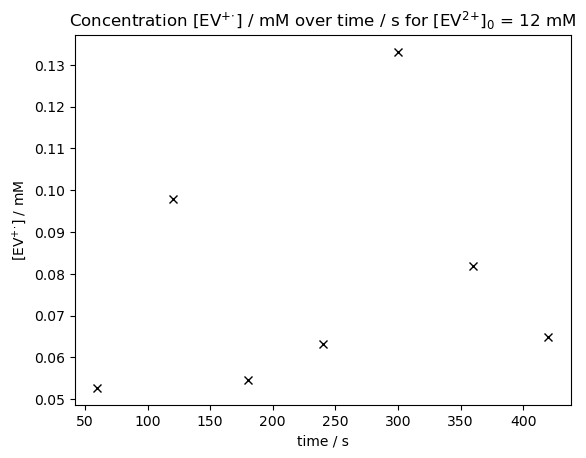

In [6]:
# concentration vs time plot for each run
c = concvstimepoints(data, peak, e, l, points, start=start)
plt.plot(tRs, [conc*1e3 for conc in c], "x", color="black") # plot time in seconds, concentrations in μM
plt.xlabel(r'time / s')
plt.ylabel(rf'{XV} / mM')
plt.title(rf'Concentration {XV} / mM over time / s for {XV0} = {c0*1e3:.0f} mM')
plt.show()

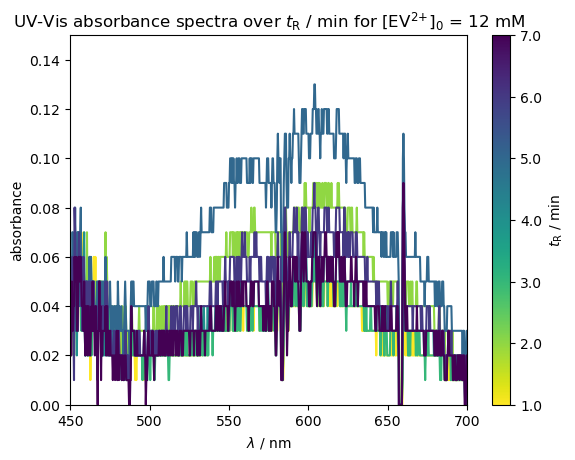

In [7]:
from matplotlib import cm as cm
from matplotlib import colors as colors

# absorbance spectra for each tR
fig, ax = plt.subplots()
cmap = plt.get_cmap("viridis_r")

l, a = spectrumvstimepoints(data, points, start=start)
for i in range(len(tRs)):
    ax.plot(l, a[i], color=cmap(i/(len(tRs)-1)))

norm = colors.Normalize(vmin=0, vmax=len(tRs)-1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_ticks(range(len(tRs)))
cbar.set_ticklabels([tR/60 for tR in tRs])
cbar.set_label(f"{tR} / min")

plt.title(rf'UV-Vis absorbance spectra over {tR} / min for {XV0} = {c0*1e3:.0f} mM')
plt.xlim(450, 700)
plt.ylim(0, 0.15)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.show()